In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [20]:
train = pd.read_parquet("../data/processed/train.parquet")
test = pd.read_parquet("../data/processed/test.parquet")
popular_items = pd.read_parquet("../data/processed/popular_items.parquet")
item_features = pd.read_parquet("../data/processed/item_features.parquet")
als_recs = joblib.load("../backend/models/als_recommendations.pkl")
model = joblib.load("../backend/models/als_model.pkl")
user_id_to_idx = joblib.load("../backend/models/user_idx.pkl")
item_idx_to_id = joblib.load("../backend/models/item_idx.pkl")
user_item_matrix = joblib.load("../backend/models/user_item_sparse.pkl")

In [21]:
train.shape, test.shape, len(als_recs)

((495761, 5), (74156, 5), 30523)

In [22]:
# popular_items에 item_idx 매핑 추가
item_id_to_idx = {v: k for k, v in item_idx_to_id.items()}

popular_items_norm = popular_items.copy()
pop_min = popular_items_norm["purchase_count"].min()
pop_max = popular_items_norm["purchase_count"].max()
popular_items_norm["pop_norm"] = (
    (popular_items_norm["purchase_count"] - pop_min) / (pop_max - pop_min + 1e-10)
)
pop_score_dict = dict(
    zip(popular_items_norm["article_id"], popular_items_norm["pop_norm"])
)

popular_items_norm.head()

,article_id,purchase_count,pop_norm
0,0706016001,702,1.000000
1,0610776002,662,0.942939
2,0759871002,635,0.904422
3,0610776001,620,0.883024
4,0599580055,600,0.854494


In [23]:
def get_hybrid_recs(uidx, alpha=0.7, n=12, candidate_n=50):
    # ALS 점수 (candidate_n개 후보 추출)
    ids, scores = model.recommend(
        uidx,
        user_item_matrix[uidx],
        N=candidate_n,
        filter_already_liked_items=False,
    )

    # ALS 점수 정규화
    s_min, s_max = scores.min(), scores.max()
    als_norm = (scores - s_min) / (s_max - s_min + 1e-10)

    # 하이브리드 점수 계산
    final_rank = []
    for iid, a_score in zip(ids, als_norm):
        article_id = item_idx_to_id.get(iid)
        if article_id is None:
            continue
        pop = pop_score_dict.get(article_id, 0.0)
        hybrid_score = alpha * a_score + (1 - alpha) * pop
        final_rank.append((article_id, hybrid_score))

    final_rank.sort(key=lambda x: x[1], reverse=True)
    return [x[0] for x in final_rank[:n]]

In [24]:
# Cold Start Fallback 포함 최종 API 함수
top_popular_list = popular_items["article_id"].head(12).tolist()
max_user_idx = model.user_factors.shape[0]


def final_recommend_api(user_id, alpha=0.7):
    uidx = user_id_to_idx.get(user_id)
    if uidx is None or uidx >= max_user_idx:
        return top_popular_list  # Cold Start → 인기 추천 fallback
    return get_hybrid_recs(uidx, alpha=alpha)

In [25]:
# 샘플 확인
sample_uid = list(als_recs.keys())[0]
sample_uidx = user_id_to_idx[sample_uid]

hybrid_result = get_hybrid_recs(sample_uidx, alpha=0.7)

pd.DataFrame({
    "rank": range(1, 13),
    "article_id": hybrid_result,
}).merge(
    item_features[["article_id", "product_type_name", "colour_group_name"]],
    on="article_id",
    how="left",
)

,rank,article_id,product_type_name,colour_group_name
0,1,0585158008,Swimwear bottom,Yellowish Brown
1,2,0800768003,Top,Yellow
2,3,0811660002,Sweater,Light Green
3,4,0699361004,Underwear bottom,Dark Red
4,5,0909831001,Dress,Dark Blue
5,6,0278811011,Underwear bottom,Beige
6,7,0720810011,Trousers,Black
7,8,0762796007,Sweater,Dark Blue
8,9,0806766001,Boots,Black
9,10,0886569005,Dress,Black


In [26]:
article_to_category = (
    item_features.set_index("article_id")["product_type_name"].to_dict()
)

user_history_categories = (
    train.assign(category=train["article_id"].map(article_to_category))
    .groupby("customer_id")["category"]
    .apply(set)
    .to_dict()
)

top_popular_set = set(top_popular_list)

# 평가 대상 유저 샘플링
np.random.seed(42)
eval_users = np.random.choice(list(als_recs.keys()), size=2000, replace=False)


def category_hit_rate(rec_list, user_id):
    hist = user_history_categories.get(user_id, set())
    if not hist:
        return 0.0
    rec_cats = {article_to_category.get(a) for a in rec_list if article_to_category.get(a)}
    return len(hist & rec_cats) / len(hist)


def catalog_coverage(all_recs_dict):
    covered = set()
    for recs in all_recs_dict.values():
        covered.update(recs)
    return len(covered) / len(item_idx_to_id)

In [27]:
popular_hits, als_hits, hybrid_hits = [], [], []
als_recs_eval, hybrid_recs_eval = {}, {}

for uid in eval_users:
    uidx = user_id_to_idx.get(uid)
    if uidx is None or uidx >= max_user_idx:
        continue

    pop_recs = list(top_popular_set)
    als_rec = als_recs.get(uid, pop_recs)
    hyb_rec = get_hybrid_recs(uidx, alpha=0.1)

    popular_hits.append(category_hit_rate(pop_recs, uid))
    als_hits.append(category_hit_rate(als_rec, uid))
    hybrid_hits.append(category_hit_rate(hyb_rec, uid))

    als_recs_eval[uid] = als_rec
    hybrid_recs_eval[uid] = hyb_rec

popular_hit_mean = np.mean(popular_hits)
als_hit_mean = np.mean(als_hits)
hybrid_hit_mean = np.mean(hybrid_hits)

popular_cov = catalog_coverage({u: list(top_popular_set) for u in eval_users})
als_cov = catalog_coverage(als_recs_eval)
hybrid_cov = catalog_coverage(hybrid_recs_eval)

pd.DataFrame({
    "모델": ["인기 추천 (Control)", "ALS 개인화 (Test)", "Hybrid α=0.7 (최종)"],
    "Hit Rate": [round(popular_hit_mean, 4), round(als_hit_mean, 4), round(hybrid_hit_mean, 4)],
    "Coverage": [round(popular_cov, 4), round(als_cov, 4), round(hybrid_cov, 4)],
})

,모델,Hit Rate,Coverage
0,인기 추천 (Control),0.3640,0.0004
1,ALS 개인화 (Test),0.2793,0.0307
2,Hybrid α=0.7 (최종),0.3697,0.0431


In [28]:
alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alpha_results = []

# 샘플 500명으로 빠르게 계산
np.random.seed(42)
alpha_eval_users = np.random.choice(list(als_recs.keys()), size=500, replace=False)
alpha_eval_users = [
    u for u in alpha_eval_users
    if user_id_to_idx.get(u) is not None
    and user_id_to_idx[u] < max_user_idx
]

for alpha in alphas:
    hits, recs_dict = [], {}
    for uid in alpha_eval_users:
        uidx = user_id_to_idx[uid]
        recs = get_hybrid_recs(uidx, alpha=alpha)
        hits.append(category_hit_rate(recs, uid))
        recs_dict[uid] = recs

    alpha_results.append({
        "alpha": alpha,
        "hit_rate": round(np.mean(hits), 4),
        "coverage": round(catalog_coverage(recs_dict), 4),
    })

alpha_df = pd.DataFrame(alpha_results)
alpha_df

,alpha,hit_rate,coverage
0,0.0,0.3617,0.0272
1,0.1,0.3724,0.0275
2,0.2,0.3695,0.0269
3,0.3,0.3689,0.0265
4,0.4,0.3643,0.0263
5,0.5,0.3649,0.0261
6,0.6,0.3644,0.0259
7,0.7,0.3552,0.0259
8,0.8,0.3588,0.0259
9,0.9,0.3565,0.0260


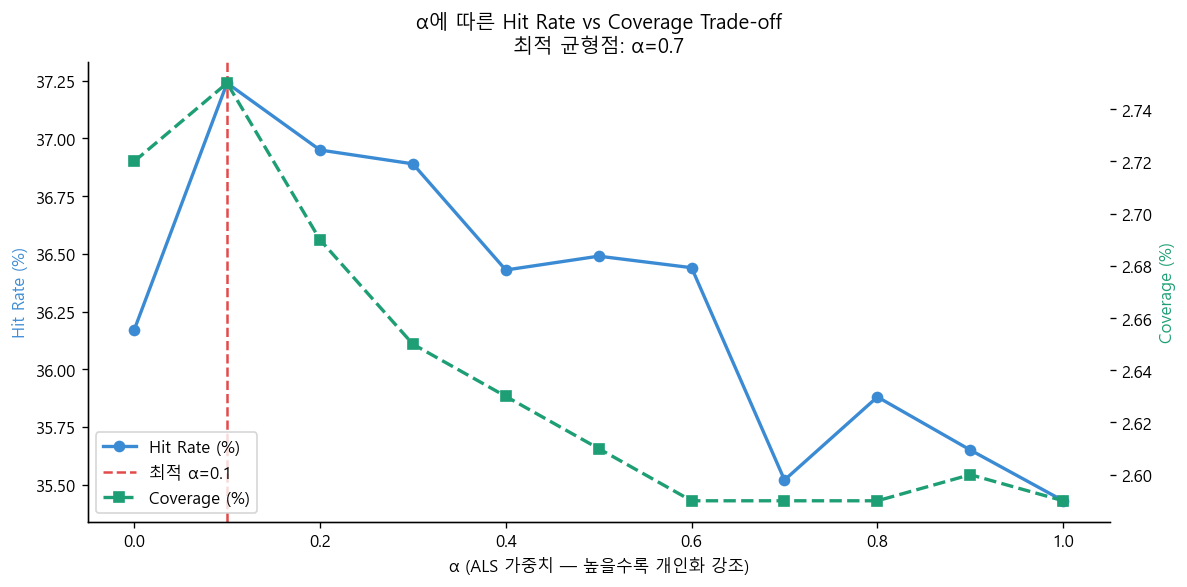

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()

ax1.plot(alpha_df["alpha"], alpha_df["hit_rate"] * 100, marker="o",
         color="#3B8BD4", linewidth=2, label="Hit Rate (%)")
ax2.plot(alpha_df["alpha"], alpha_df["coverage"] * 100, marker="s",
         color="#1D9E75", linewidth=2, linestyle="--", label="Coverage (%)")

ax1.axvline(x=0.1, color="#E24B4A", linestyle="--", linewidth=1.5,
            label="최적 α=0.1")

ax1.set_xlabel("α (ALS 가중치 — 높을수록 개인화 강조)")
ax1.set_ylabel("Hit Rate (%)", color="#3B8BD4")
ax2.set_ylabel("Coverage (%)", color="#1D9E75")
ax1.set_title("α에 따른 Hit Rate vs Coverage Trade-off\n최적 균형점: α=0.7")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.savefig("../data/processed/fig_alpha_tradeoff.png", bbox_inches="tight")
plt.show()

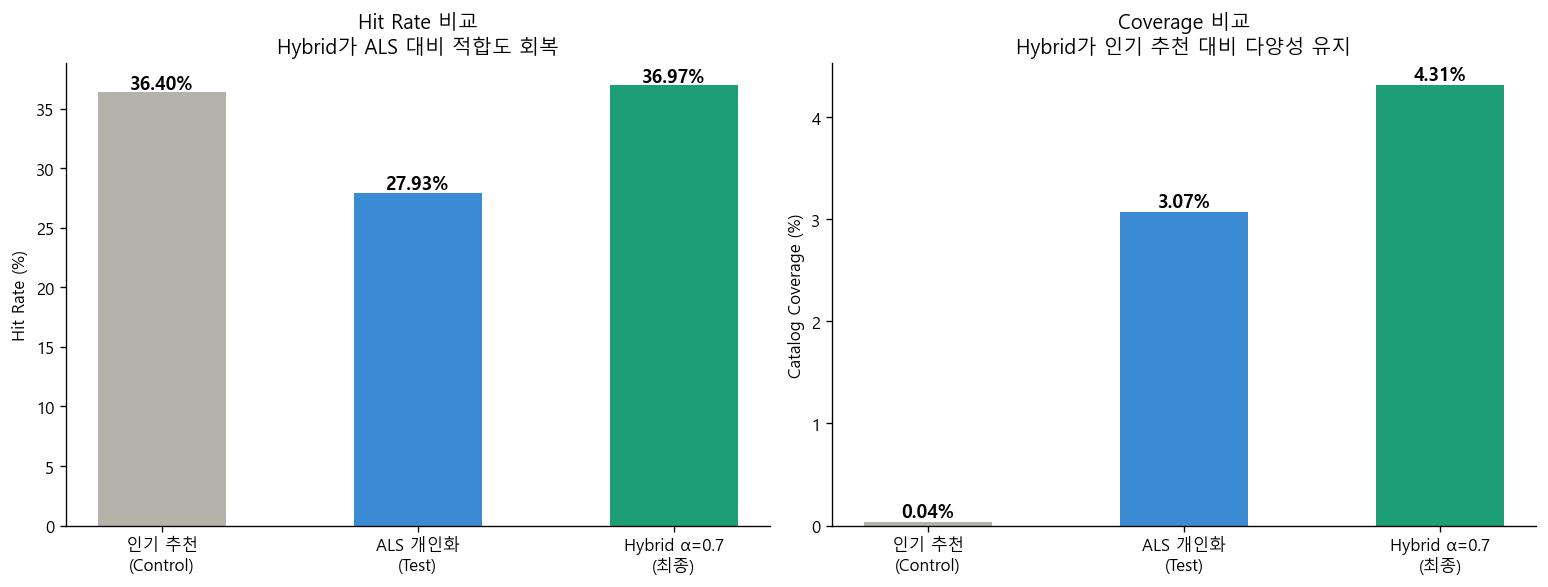

In [30]:
models = ["인기 추천\n(Control)", "ALS 개인화\n(Test)", "Hybrid α=0.7\n(최종)"]
hit_vals = [popular_hit_mean * 100, als_hit_mean * 100, hybrid_hit_mean * 100]
cov_vals = [popular_cov * 100, als_cov * 100, hybrid_cov * 100]
colors = ["#B4B2A9", "#3B8BD4", "#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(models, hit_vals, color=colors, width=0.5)
for bar, v in zip(bars, hit_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{v:.2f}%",
        ha="center", fontsize=11, fontweight="bold",
    )
axes[0].set_ylabel("Hit Rate (%)")
axes[0].set_title("Hit Rate 비교\nHybrid가 ALS 대비 적합도 회복")

bars2 = axes[1].bar(models, cov_vals, color=colors, width=0.5)
for bar, v in zip(bars2, cov_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{v:.2f}%",
        ha="center", fontsize=11, fontweight="bold",
    )
axes[1].set_ylabel("Catalog Coverage (%)")
axes[1].set_title("Coverage 비교\nHybrid가 인기 추천 대비 다양성 유지")

plt.tight_layout()
plt.savefig("../data/processed/fig_three_way.png", bbox_inches="tight")
plt.show()

#### Step 7 — 통계 검정 (Hybrid vs Control)

In [31]:
t_stat, p_value = stats.ttest_rel(hybrid_hits, popular_hits)
lift = (hybrid_hit_mean - popular_hit_mean) / popular_hit_mean * 100

pd.DataFrame({
    "항목": [
        "Control Hit Rate (인기 추천)",
        "Hybrid Hit Rate (α=0.1)",
        "Hit Rate 개선",
        "T-statistic (대응표본)",
        "P-value",
        "결론",
    ],
    "값": [
        f"{popular_hit_mean:.4f}",
        f"{hybrid_hit_mean:.4f}",
        f"{lift:+.1f}%",
        f"{t_stat:.4f}",
        f"{p_value:.4f}",
        "유의미한 차이 있음" if p_value < 0.05 else "유의미한 차이 없음",
    ],
})

,항목,값
0,Control Hit Rate (인기 추천),0.3640
1,Hybrid Hit Rate (α=0.1),0.3697
2,Hit Rate 개선,+1.6%
3,T-statistic (대응표본),0.6288
4,P-value,0.5295
5,결론,유의미한 차이 없음


#### Step 8 — ab_results.json 업데이트

In [32]:
ab_results_final = {
    "summary": {
        "control_cvr": round(popular_hit_mean, 4),
        "test_cvr": round(hybrid_hit_mean, 4),
        "als_cvr": round(als_hit_mean, 4),
        "cvr_lift_pct": round(lift, 2),
        "z_stat": round(float(t_stat), 4),
        "p_value": round(float(p_value), 4),
        "significant": bool(p_value < 0.05),
        "n_eval": len(hybrid_hits),
        "metric": "Category Hit Rate",
        "optimal_alpha": 0.1,
        "catalog_coverage_control": round(popular_cov, 4),
        "catalog_coverage_als": round(als_cov, 4),
        "catalog_coverage_hybrid": round(hybrid_cov, 4),
    },
    "alpha_tradeoff": alpha_df.to_dict(orient="records"),
}

with open("../data/processed/ab_results.json", "w", encoding="utf-8") as f:
    json.dump(ab_results_final, f, ensure_ascii=False, indent=2)

pd.DataFrame([ab_results_final["summary"]])

,control_cvr,test_cvr,als_cvr,cvr_lift_pct,z_stat,p_value,significant,n_eval,metric,optimal_alpha,catalog_coverage_control,catalog_coverage_als,catalog_coverage_hybrid
0,0.364,0.3697,0.2793,1.56,0.6288,0.5295,False,2000,Category Hit Rate,0.1,0.0004,0.0307,0.0431


#### Step 9 — Hybrid 추천 전체 저장

In [33]:
# 전체 유저 Hybrid 추천 생성 및 저장
hybrid_all_recs = {}

for uid in list(als_recs.keys()):
    uidx = user_id_to_idx.get(uid)
    if uidx is None or uidx >= max_user_idx:
        hybrid_all_recs[uid] = get_hybrid_recs(uidx, alpha=0.1)
        continue
    hybrid_all_recs[uid] = get_hybrid_recs(uidx, alpha=0.7)

joblib.dump(hybrid_all_recs, "../backend/models/hybrid_recommendations.pkl")
len(hybrid_all_recs)

30523